<div style="background-color: #FAF7F5; padding: 16px; border-radius: 5px;">
    

# 📊 Proyecto: Análisis Comercial Inmobiliario

El sector inmobiliario necesita evaluar su **desempeño comercial** para comprender su crecimiento, rentabilidad y comportamiento de clientes.

Se solicita construir un **dashboard ejecutivo** que permita analizar ventas, clientes y propiedades para apoyar decisiones estratégicas basadas en datos.
</div>

<div style="background-color: #FAF7F5; padding: 16px; border-radius: 5px;">
    
# 📂 Descripción de los Datasets

🔹 **hecho_ventas_propiedades**  
Tabla de hechos con las transacciones de venta (precio, cliente, propiedad, canal, fecha).

🔹 **dim_clientes**  
Información y segmentación de clientes.

🔹 **dim_propiedades**  
Características de las propiedades (tipo, tamaño, ubicación, etc).

🔹 **dim_fecha**  
Tabla calendario auxiliar que será creada como parte del modelado.
</div>

<div style="background-color: #FAF7F5; padding: 16px; border-radius: 5px;">

# 🎯 Preguntas que el dashboard debe responder

**Desempeño general**

- ¿Cuál es el **ingreso total** generado por la empresa?
- ¿Cuántas **propiedades se han vendido**?
- ¿Cuál es el **precio promedio de venta**?
- ¿Cuál es la **comisión total** generada por la empresa?

**Análisis comercial**

- ¿Qué **tipo de propiedad genera más ingresos**?
- ¿Qué **segmento de clientes compra más propiedades**?
- ¿Qué canal de venta **genera mayor ingresos**?


**Análisis temporal**

- ¿Cómo evolucionan las **ventas en el tiempo**?
- ¿El negocio está **creciendo año contra año**?
- ¿Cómo va el desempeño **acumulado del año actual (YTD)**?

**Cohortes de clientes**

- ¿Los clientes **vuelven a comprar** después de su primera compra?
- ¿Qué **cohortes de clientes generan más compras/ingresos con el tiempo**?
</div>

<div style="background-color: #FAF7F5; padding: 16px; border-radius: 5px;">
    
## 🧹 Paso 1: Limpieza de datos

Antes del modelado, procederemos a validar y depurar la información bajo estas directrices:

### Tipos de datos

- `fecha_venta` debe estar en formato **Date**.
- Los campos numéricos deben estar correctamente formateados.
- `porcentaje_comision` debe estar en formato **porcentaje**.

### Valores nulos

- Se revisarán valores **nulos** en las tablas.
- Se justificar+a si deben eliminarse o mantenerse.

### Duplicados

- Se validará que no existan duplicados en las claves primarias de:
  - `dim_clientes`
  - `dim_propiedades`
</div>

<div style="background-color: #f2f2f2; padding: 16px; border-radius: 5px;">

## Limpieza de Datos (revisión de la calidad de los datasets)

### Preparación de la carga a Power BI
- **Preparación de los datasets en archivo Excel para carga**<br>
Se unificaron los tres archivos csv (`hecho_ventas_propiedades`,`dim_clientes`, `dim_propiedades`) en un libro de Excel conjunto para la carga de los datasets a Power BI: `Andes_Capital_RE_2023_2024.xslx` (se agrega a la carpeta del proyecto)<br>

- **Corrección de problemas de codificación**<br>
Se corrigieron problemas de codificación al importar los archivos texto/CSV para crear el archivo excel conjunto para la carga (se especificó la codificación correcta **65001: Unicode (UTF-8)**). Al tomarse la codificación correcta en el archivo de carga se corrigieron los registros que presentaban caracteres incorrectos en las columnas:
  - `hecho_ventas_propiedades`: columna `ciudad` (BogotÃ¡, Ciudad de MÃ©xico).<br>
  - `dim_clientes`: columna `ciudad` (BogotÃ¡, Ciudad de MÃ©xico); columna `país` (se corrigió ortografía del valor "México" mediante sustitución)<br>
  - `dim_propiedades`: columna `ciudad` (BogotÃ¡, Ciudad de MÃ©xico) y columna `barrio` (UsaquÃ©n, CoyoacÃ¡n, etc.)<br>

### Tipos de datos
- **Inconsistencias con tipos de dato**<br>
En Power BI, ya cargados los datasets se cambiaron los tipos de dato:
  - **En la tabla `hecho_ventas_propiedades`:**
    - Se cambió configuración regional de `fecha_venta` a Español(Latinoamérica)<br>
    - Se cambió el tipo de la columna `precio_venta` a Numérico Decimal<br>
    - Se cambió el tipo de la columna `monto_comision` a Numérico Decimal<br>
    - Se cambió el tipo de la columna `porcentaje_comisión` a Porcentaje<br>
  - **En la tabla `dim_propiedades`:**
    - Se cambió el tipo de la columna `precio_publicado` a Numérico Decimal<br>
  - **En la tabla `dim_clientes`:** no se realizaron cambios, las columnas categóricas permanecen tipo texto

### Valores nulos
- **Valores nulos:** No se encontraron valores nulos en ninguna de las tres tablas ni valores disfrazados de nulo como celdas vacías, NaN, guiones, etc.<br>

### Duplicados
- **Validación de duplicados en las claves primarias:**<br>
Todas las llaves primarias son únicas, sin problemas de doble conteo.<br>
El modelo está limpio sin nulos, sin duplicados, sin problemas de integridad referencial.<br>
</div>

<div style="background-color: #f2f2f2; padding: 16px; border-radius: 5px;">


### Valores categóricos
Todas las columnas presentan únicamente los valores esperados, sin categorías mal escritas, duplicadas o inesperadas. No se requiere corrección alguna.<br>

- **`hecho_ventas_propiedades`:** <br>
**ciudad**: Ciudad de México, Bogotá <br>
**tipo_propiedad**: Dapartamento, Casa, Comercial <br>
**canal_venta**: Corredor, Directo <br>
 
- **`dim_propiedades`:**<br>
**tipo_propiedad**: Dapartamento, Casa, Comercial <br>
**ciudad**: Ciudad de México, Bogotá <br>
**barrio**: 20 barrios distintos <br>
**categoria_propiedad**: Residencial, Comercial <br>

- **`dim_clientes`:**<br>
**segmento_comprador**: Primera vez, Inversionista, Alto patrimonio <br>
**pais**: México, Colombia <br>
**ciudad**: Ciudad de México, Bogotá <br>

**Se ocultó el campo `tipo_propiedad` de la tabla `hecho_ventas_propiedades` (en la Vista Modelo) para evitar redundancia (por que ya está especificado en la tabla dimensión dim_propiedades)**
</div>

<div style="background-color: #FAF7F5; padding: 16px; border-radius: 5px;">
    
## 📅 Paso 2: Creación de tabla calendario

Se creará una tabla calendario llamada **dim_fecha** para realizar el dashboard en **Power BI**.

**Requisitos (solo para Power BI):**
- Se utilizarán las funciones `CALENDAR` y `ADDCOLUMNS`.
- El rango de fechas se construirá dinámicamente desde la **fecha mínima** hasta la **fecha máxima** de ventas en `hecho_ventas_propiedades`.
- Se incluirán como mínimo las siguientes columnas:
  - Año
  - Mes (nombre)
  - Número de mes
  - Año-Mes (formato `YYYY-MM`)

> ⚠️ **Nota:**  
> En caso de utilizar **Tableau**, no sería necesario crear esta tabla. Se usaría directamente el campo `fecha_venta` de la tabla `hecho_ventas_propiedades`, ya que Tableau genera automáticamente las jerarquías de fecha.
</div>

<div style="background-color: #f2f2f2; padding: 16px; border-radius: 5px;">

### Creación de Tabla Calendario
    
- **Se creó la tabla calendario con el siguiente código:** <br>
  <small> dim_Fecha = <br>
    ADDCOLUMNS(<br>
    CALENDAR( MIN(hecho_ventas_propiedades[fecha_venta]), MAX(hecho_ventas_propiedades[fecha_venta]) ),<br>
    "Año", YEAR([Date]),<br>
    "Mes", FORMAT([Date], "MMMM"),<br>
    "Mes Numero", MONTH([Date]),<br>
    "Año-Mes", FORMAT([Date], "YYYY-MM") ) </small> 

- **Se incorporó la tabla dim_fecha al modelo estrella conectando las tablas a través de los campos date/fecha_venta , cuidando la cardinalidad 1 a muchos, la dirección del filtro y la relación en estado activo**.
    
</div>

<div style="background-color: #FAF7F5; padding: 16px; border-radius: 5px;">
    
## 🧩 Paso 3: Modelado de datos

### Modelo requerido: Esquema estrella

El modelo se estructurará en formato estrella:

- `hecho_ventas_propiedades` como tabla central.
- Tablas dimensionales conectadas:
  - `dim_clientes`
  - `dim_propiedades`
  - `dim_fecha` (creada por ti, en caso de que aplique)

Requisitos de las relaciones:

- Cardinalidad **uno a muchos (1:*)**
- Dirección de filtro **simple (single)**
- Relaciones basadas en las claves correctas
- Todas las relaciones deben estar **activas**
- </div>

<div style="background-color: #f2f2f2; padding: 16px; border-radius: 5px;">
    
### Creación del Modelo Estrella
- **Estructura estrella confirmada:** `hecho_ventas_propiedades` está en el centro y las dimensiones `dim_clientes`, `dim_propiedades` y `dim_Fecha` la rodean.
- **Cardinalidad 1:muchos (con dirección única):** todas las relaciones van de la dimensión (1) hacia la tabla de hechos (*), con filtrado en un solo sentido.
- **Claves técnicas ocultas:** `id_cliente`, `id_propiedad` e `id_venta` están ocultas tanto en la tabla de hechos como en sus respectivas dimensiones (visibles solo como relaciones).
- **Los filtros provienen siempre de las tablas de dimensiones:** el contexto de filtro fluye de dimensión a hechos, no al revés.
- **No existen relaciones entre dimensiones:** Sin relaciones entre `dim_clientes`, `dim_propiedades` y `dim_Fecha` ya que no están conectadas entre sí directamente, solo a través de la tabla de hechos (evitando rutas de filtrado ambiguas o ciclos).
- También **se ocultó el campo `tipo_propiedad` de la tabla `hecho_ventas_propiedades`** para tomar sólo el valor de la tabla dimensión dim_propiedades).
  
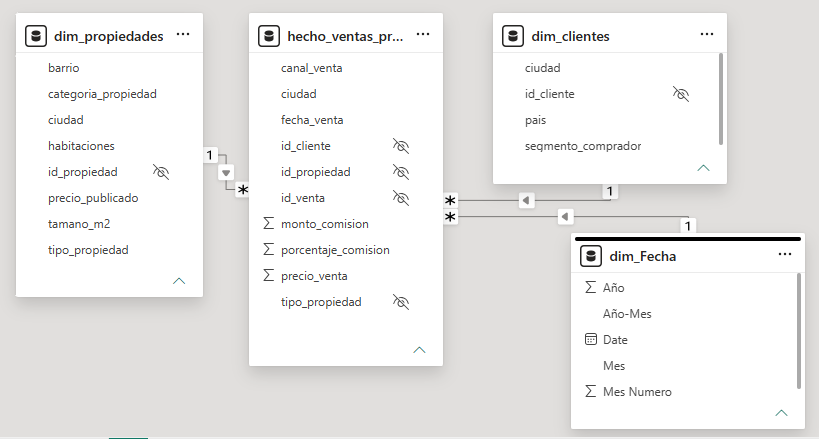
</div>


<div style="background-color: #FAF7F5; padding: 16px; border-radius: 5px;">
    
## 📊 Paso 4: Creación de medidas

En este paso se crearáb las **medidas necesarias para responder las preguntas de negocio del dashboard**.

Las medidas serán implementadas en **Power BI (DAX)** (no se utilizarán los **Calculated Fields en Tableau**).

---

### 4.1 🔹 Medidas base

Se crearán las siguientes medidas:
- **Ingreso Total** (suma del `precio_venta`)
- **Cantidad de Ventas**
- **Ticket Promedio**
- **Comisión Total**

Estas métricas permitirán analizar el desempeño general del negocio.

---

### 4.2 🔹 Medidas con contexto de filtro

Se crearán **al menos 2 medidas** que modifiquen el contexto de filtro.

En este caso se utilizarán **medidas de participación (%)**, que permiten entender **qué proporción del ingreso total aporta cada categoría**.

Las medidas que se construirán son:

- **Participación de ingresos por tipo de propiedad**
- **Participación de ingresos por canal de venta**
- **Participación de ingresos por segmento de cliente**

Para ello:
- Se modificará el contexto de filtro con las funciones propias de cada herramienta
  - En Power BI, usa `CALCULATE`
  - No se utilizarán en Tableau, expresiones como `FIXED` (LOD)

Se eliminará el filtro de la dimensión correspondiente para obtener el total.<br>
Es necesario asegurar que el denominador represente el total sin el filtro de la categoría, mientras que el numerador sí lo conserve.<br>
Estas medidas se utilizarán principalmente como **tooltip o etiqueta adicional en los gráficos** del dashboard para complementar el análisis.<br>

---

### 4.3 🔹 Inteligencia de tiempo

Utilizando la tabla **`dim_fecha`** (Power BI) se crearán las siguientes medidas:

- **Ventas Year to Date (YTD)**
- **Ventas Month to Date (MTD)**
- **Ventas del año anterior**
- **Crecimiento Year over Year (YoY)**

Estas métricas permitirán analizar la evolución del negocio en el tiempo.

---

### 4.4 🔹 Medidas para análisis de cohortes

Se crearán cálculos que permitan analizar **si los clientes vuelven a comprar después de su primera compra**.

⚠️ Estos cálculos se crearán como **columnas calculadas**, no como medidas.  
Todas se crearán en la tabla **`hecho_ventas_propiedades`**.

Se crearán las siguientes columnas calculadas:

- **Primera compra por cliente** → fecha mínima de compra de cada cliente.
- **Mes Cohorte** → mes en que el cliente realizó su **primera compra** (mes de adquisición).
- **Mes Venta** → mes en que ocurre cada transacción. Este campo permite identificar **cuándo el cliente vuelve a comprar** después de su primera compra.

Estos cálculos permitirán construir una **matriz de cohortes** donde:

- **Filas** representen el **mes de cohorte**
- **Columnas** representen el **mes de venta**
- **Valores** muestren **cantidad de ventas o ingresos**

---
</div>

<div style="background-color: #f2f2f2; padding: 16px; border-radius: 8px;">
    
### Creación de medidas
    
### Medidas Base
- **Ingreso Total** --> mb_ingreso_total = SUM(hecho_ventas_propiedades[precio_venta])
- **Cantidad de Ventas** --> mb_cantidad_de_ventas = DISTINCTCOUNT(hecho_ventas_propiedades[id_venta])
- **Ticket Promedio** --> mb_ticket_promedio = DIVIDE([mb_ingreso_total],[mb_cantidad_de_ventas], 0)
- **Comisión Total** --> mb_comision_total = SUM(hecho_ventas_propiedades[monto_comision])

### Medidas con contexto de filtro
- **Participación de ingresos por tipo de propiedad**<br>
--> mf_p_ingreso_total_global = CALCULATE([mb_ingreso_total], ALL(dim_propiedades))<br>
--> mf_p_%_ingreso = DIVIDE([mb_ingreso_total], [mf_p_ingreso_total_global])  <br>
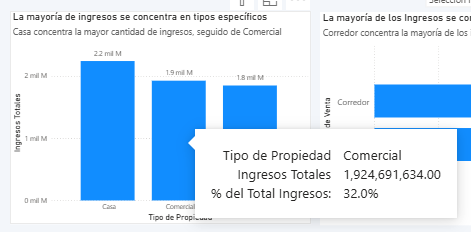

- **Participación de ingresos por canal de venta**<br>
--> mf_c_ingreso_total_global = CALCULATE([mb_ingreso_total], ALL(hecho_ventas_propiedades))<br>
--> mf_c_%_ingreso = DIVIDE([mb_ingreso_total], [mf_c_ingreso_total_global]) <br>
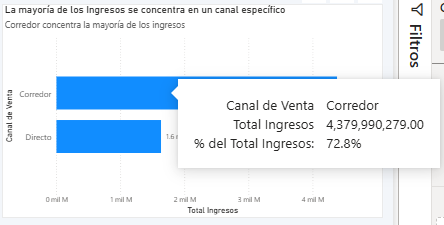

- **Participación de ingresos por segmento de cliente**<br>
--> mf_s_ingreso_total_global = CALCULATE([mb_ingreso_total], ALL(dim_clientes))<br>
--> mf_s_%_ingreso = DIVIDE([mb_ingreso_total], [mf_s_ingreso_total_global])<br>
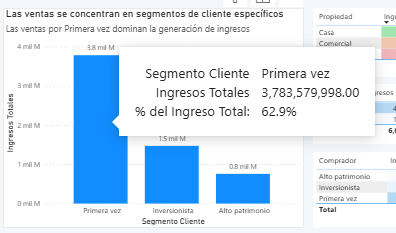

### Medidas de Inteligencia de tiempo
- **Ventas Year to Date (YTD)** --> mt_ventas_YTD = TOTALYTD([mb_ingreso_total], Dim_Fecha[Date] )
- **Ventas Month to Date (MTD)** --> mt_ventas_MTD = TOTALMTD([mb_ingreso_total], Dim_Fecha[Date] ) 
- **Ventas del año anterior** --> mt_ventas_ano_anterior = CALCULATE( [mb_ingreso_total], DATEADD(Dim_Fecha[Date], -1, YEAR) ) 
- **Crecimiento Year over Year (YoY)** --> mt_yoy_% = DIVIDE([mb_ingreso_total] - [mt_ventas_ano_anterior], [mt_ventas_ano_anterior] ) 


### Medidas para análisis de cohortes
**Columnas Calculadas:**
- **Primera compra por cliente**<br>
--> tc_primera_compra = CALCULATE(MIN(hecho_ventas_propiedades[fecha_venta]), ALLEXCEPT(hecho_ventas_propiedades, hecho_ventas_propiedades[id_cliente]) )
- **Mes Cohorte**<br>
--> tc_cohorte = FORMAT([tc_primera_compra], "YYYY-MM")
- **Mes desde Inicio**<br>
--> tc_meses_desde_inicio = DATEDIFF([tc_primera_compra], hecho_ventas_propiedades[fecha_venta], MONTH)

**Armado de la Matriz:**
- **Número de Clientes**<br>
--> tc_m_clientes = DISTINCTCOUNT(hecho_ventas_propiedades[id_cliente])
  
- **% de Retención**<br>
--> tc_m_%_retencion = DIVIDE( DISTINCTCOUNT(hecho_ventas_propiedades[id_cliente]),CALCULATE( DISTINCTCOUNT(hecho_ventas_propiedades[id_cliente]), hecho_ventas_propiedades[tc_meses_desde_inicio] = 0 ) ) 

</div>

<div style="background-color: #FAF7F5; padding: 16px; border-radius: 5px;">

## 📊 Paso 5: Estructura del reporte

El dashboard contendrá **tres páginas**.

---

### 5.1 1️⃣ Overview Ejecutivo

Muestra **el desempeño general del negocio**.

Se incluyen los KPIs:

- **KPIs principales**  
  - Ingreso Total  
  - Cantidad de Ventas  
  - Ticket Promedio  
  - Comisión Total  

- **Tendencia de ventas en el tiempo**

- **Ingresos o ventas por ciudad**

- **Crecimiento Year over Year (YoY)**

---

### 5.2 2️⃣ Análisis Comercial

En esta página se analiza **qué productos, canales y clientes generan más ingresos**.

Incluye:

- **Ingreso por tipo de propiedad**
- **Ventas o ingresos por canal de venta**
- **Ventas o ingresos por segmento de cliente**
- **Tabla con formato condicional (colores semáforo)**  
  Se agregan los campos:
  - tipo_propiedad
  - Ingreso Total
  - Cantidad Ventas
  - Ticket Promedio  
  Se aplica **formato condicional** para resaltar las categorías con mayor desempeño.

Se agregarán **tooltips con medidas de participación (%)**.

---

### 5.3 3️⃣ Análisis de Cohortes

En esta página se analizará **recurrencia de clientes**.

Se incluye:

- **Matriz de cohortes**
  - Filas → Mes Cohorte
  - Columnas → Mes Venta
  - Valores → Cantidad Ventas o Ingreso Total

Esto permitirá observar **si los clientes vuelven a comprar y comparar cohortes en el tiempo**.

</div>

<div style="background-color: #f2f2f2; padding: 16px; border-radius: 5px;">

## Estructura del reporte

### 1️⃣ Overview Ejecutivo
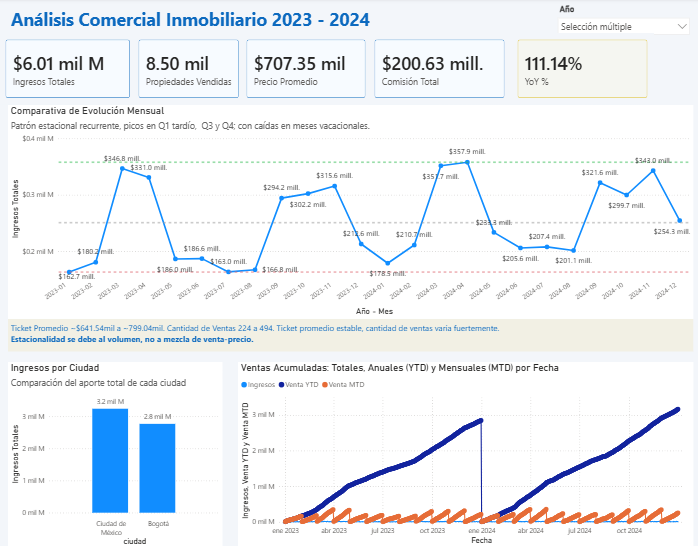

### 2️⃣ Análisis Comercial
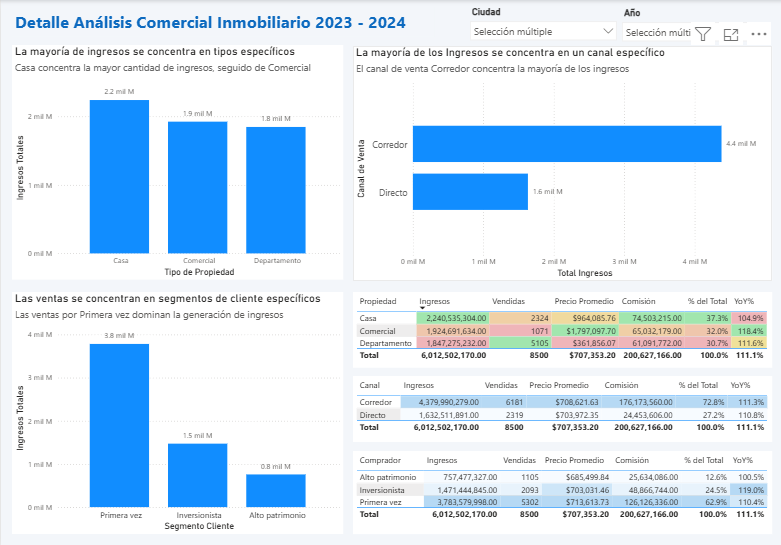

### 5.3 3️⃣ Análisis de Cohortes
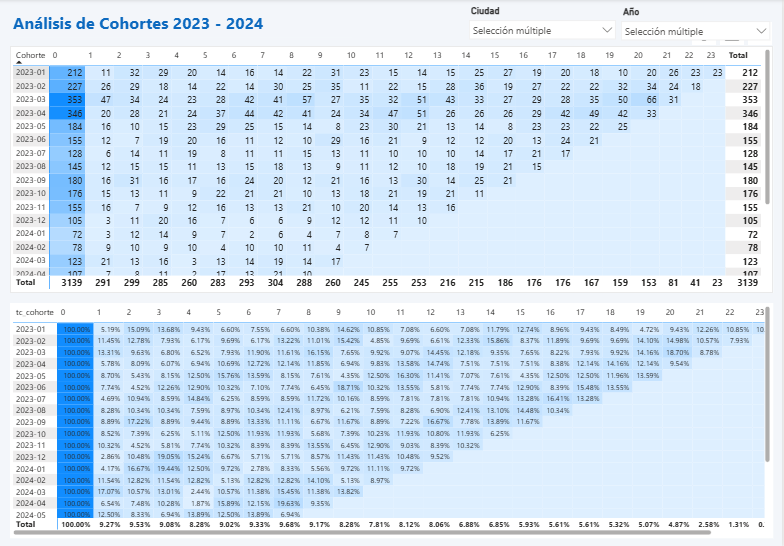

</div>

<div style="background-color: #FAF7F5; padding: 16px; border-radius: 5px;">
    
## 📝Paso 6:  Resumen Ejecutivo

Se incluyen aquí:
- hallazgos clave
- métricas principales
- insights accionables
- recomendaciones estratégicas
</div>

<div style="background-color: #f2f2f2; padding: 16px; border-radius: 5px;">
    
## Resumen Ejecutivo

**Hallazgos clave**
- El ingreso total del periodo fue de **`$6,012,502,170.00`** generado por **8500** ventas.
- El tipo de propiedad que genera mayor revenue es `Casa` con **`$2,240,535,304.00`**. <small>(seguido por Comercial: `$1,924,691,634.00` y Departamento: `$1,847,275,232.00`).</small>
- La ciudad con mayor volumen de ventas es `Ciudad de México` con **`$3,242,231,285.00`**.<small> (Bogotá `$2,770,270,885.00`)</small>
- El canal de venta más eficiente en términos de ingresos es `Corredor` con **`$4,379,990,279.00`**.<small> (Directo `$1,632,511,891.00`)</small>
- Se observa un patrón de estacionalidad en la evolución de ventas en el tiempo (ambos años, ambas ciudades): `Pico en marzo-abril, caída en mayo-agosto, segundo pico en septiembre-noviembre, ligera caída en diciembre`. <small>(El ticket promedio se mantiene estable (`$641`mil-`$799mil`) pero el número de ventas varía fuertemente (224-494, casi el doble entre min y max) sugiere que la estacionalidad es un fenómeno de volumen, las caídas se deben a menos ventas no venta de propiedades más baratas).</small>

**Métricas principales**
- Ingreso Total: **`$6,012,502,170.00`**
- Cantidad de Ventas: **`8500`** 
- Ticket Promedio: **`$707,353.20`** 
- Comisión Total: **`$200,627,166.00`**

**Insights accionables**
- El segmento de clientes `Clientes primera vez` (**`$3,783,579,998.00`**) concentra la mayor parte del ingreso.<small> (Inversionista `$1,471,444,845.00` y Alto patrimonio `$757,477,327.00`)</small>
- Los clientes adquiridos en las cohortes de 2023 en especial las primeras de `2023-01` a `2023-04` concentran la mayor recurrencia.
- Las ventas muestran un crecimiento de **`11.14%`** YoY.

**Recomendaciones estratégicas**
- Priorizar la comercialización de propiedades tipo `Casa`.
- Fortalecer el canal de ventas `Corredor` que presenta mayor participación en el revenue.
- Implementar estrategias de retención para `mejorar la recompra en cohortes recientes`.
- Ya que en los meses valle existen menos compradores en el mercado se recomienda `implementar acciones de marketing que incentiven la demanda sin erosionar el precio` (anticipar acciones de marketing, incentivos no ligados al precio, apalancarse con segmentos de cliente y canales de venta dominantes)
</div>